# Task 4

First, train a CNN MNIST model and create adversarial images to classify 4s as 9s. HINT: Take help from Jasoni Carter GitHub. Try to reason how these adversarial images are produced. Next, a random noise image was used to classify it as nine and observe the results. Compare the results from the first and second steps.

We're going to do three things:

1. Train a CNN to recognize MNIST digits (0–9). Roughly 99% test accuracy.
2. Trick the CNN into thinking a clearly-written 4 is actually a 9, by adding a tiny invisible perturbation to the image.
3. Start from pure random noise and modify it pixel-by-pixel until the CNN is very confident it's looking at a 9 - even though it still does not visually resemble a 9.

### How it works

When we train a network, the image stays still and the weights change to reduce loss.

An adversarial attack does the opposite: the weights stay frozen and we change the pixels to fool the network into a wrong answer.

### FGSM (Fast Gradient Sign Method)

The original FGSM paper (Goodfellow et al. 2015, "Explaining and Harnessing Adversarial Examples") shows this with a panda image: a tiny noise pattern is added, and the classifier flips to "gibbon" with 99% confidence. To us the image still looks unchanged.

The procedure:

1. Pretend the image's label is the class we want the network to pick (9).
2. Compute the loss with that fake label.
3. Look at the gradient of the loss with respect to the pixels (not the weights).
4. Nudge each pixel slightly by a tiny amount, in the direction that makes the fake label more likely.

We use only the sign of the gradient (so every pixel moves by the same tiny amount), that's why it stays invisible to the eye.


### Step 1 : Setup

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

# Pick the best device available: CUDA > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Running on:', device)

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Running on: cuda


### Load MNIST

MNIST = 70,000 grayscale images of handwritten digits, each 28×28 pixels. We'll use 60k for training and 10k for testing.

Note: CNNs need 2D input, so we keep the images as 2D (28×28), unlike the GAN code that flattens them. 

100%|██████████| 9.91M/9.91M [00:01<00:00, 7.08MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 263kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.31MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.76MB/s]


Training images: 60000
Test images:     10000


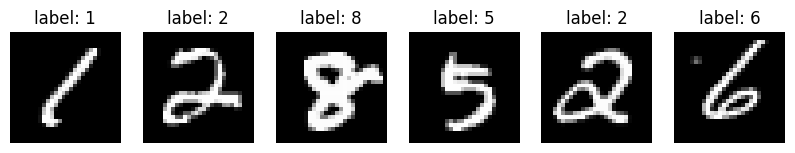

In [12]:
# transforms.ToTensor() converts the PIL image into a float tensor with values in [0, 1]
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./MNIST', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./MNIST', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=512, shuffle=False)

print(f'Training images: {len(train_dataset)}')
print(f'Test images:     {len(test_dataset)}')

# Quick peek at a few images
examples, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for ax, img, lbl in zip(axes, examples[:6], labels[:6]):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'label: {lbl.item()}')
    ax.axis('off')
plt.show()


### Step 2 : Build and train a CNN classifier

Our CNN has:
- Conv layer 1: 1 input channel -> 32 output channels, looking at 3×3 patches
- Conv layer 2: 32 -> 64 channels, again 3×3 patches
- A fully-connected layer (128 neurons) and a final layer with 10 outputs (one per digit)
- MaxPool between conv layers to shrink the image (28 -> 14 -> 7)
- Dropout to prevent overfitting

The output is logits (raw scores). We'll convert them to probabilities with softmax when we want to read predictions. Cross-entropy loss expects logits directly, so we don't add a softmax inside the model.

In [13]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 1 -> 32 channels, kernel 3x3, padding to keep size 28x28
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # 32 -> 64 channels
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # After two 2x2 maxpools: 28 -> 14 -> 7. So flat input = 64 * 7 * 7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)         # 10 classes (digits 0-9)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = F.relu(self.conv1(x))           # conv -> activation
        x = F.max_pool2d(x, 2)              # halve H and W: 28 -> 14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)              # 14 -> 7
        x = x.view(x.size(0), -1)           # flatten for the linear layer
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)                     # logits, no softmax
        return x

model = CNN().to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {n_params:,}')

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)

Total parameters: 421,642


### Train the CNN

Standard supervised training:
- Optimizer: Adam
- Loss: Cross-entropy
- Epochs: 5

We measure both training accuracy (how well it does on data it has seen) and test accuracy (data it hasn't seen).

In [14]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Train the model for one pass over the training data."""
    model.train()  # turn on dropout, batchnorm in train mode
    total_loss = 0
    correct = 0
    for x, y in tqdm(loader, leave=False, desc='train'):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()        # reset gradients
        logits = model(x)            # forward pass
        loss = criterion(logits, y)  # how wrong are we?
        loss.backward()              # compute gradients
        optimizer.step()             # update weights
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy

@torch.no_grad()
def evaluate(model, loader):
    # Compute accuracy on a dataset (no gradients).
    model.eval()  # turn off dropout
    correct = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(1)
        correct += (preds == y).sum().item()
    return correct / len(loader.dataset)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

EPOCHS = 5
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    test_acc = evaluate(model, test_loader)
    print(f'Epoch {epoch}/{EPOCHS} | loss {train_loss:.4f} | train acc {train_acc:.4f} | test acc {test_acc:.4f}')

Epoch 1/5 | loss 0.3033 | train acc 0.9081 | test acc 0.9762


Epoch 2/5 | loss 0.0781 | train acc 0.9765 | test acc 0.9842


Epoch 3/5 | loss 0.0567 | train acc 0.9823 | test acc 0.9893


Epoch 4/5 | loss 0.0457 | train acc 0.9862 | test acc 0.9890


Epoch 5/5 | loss 0.0379 | train acc 0.9882 | test acc 0.9899


With a trained CNN (close to 99% accuracy) in place, we can now run the adversarial attack.


### Step 3 : Make the CNN see a 4 as a 9 (targeted adversarial attack)


1. Find a real image of a 4 from the test set that the CNN currently classifies as 4.
2. Run our iterative FGSM attack to nudge the pixels so the CNN starts predicting 9.
3. Look at the original and adversarial images side by side. The two images should look visually identical, but the CNN's prediction will have flipped.

CNN predicts: 4 with confidence 1.0000


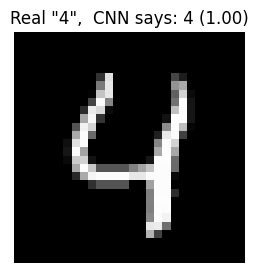

In [15]:
# Find a clean '4' that the CNN classifies correctly
model.eval()
x_orig = None
for x, y in test_loader:
    for i in range(x.size(0)):
        if y[i].item() == 4:
            candidate = x[i:i+1].to(device)
            with torch.no_grad():
                pred = model(candidate).argmax(1).item()
            if pred == 4:
                x_orig = candidate
                break
    if x_orig is not None:
        break

# Show it and the CNN's prediction
with torch.no_grad():
    probs = F.softmax(model(x_orig), dim=1).cpu().numpy()[0]

print(f'CNN predicts: {probs.argmax()} with confidence {probs.max():.4f}')
plt.figure(figsize=(3, 3))
plt.imshow(x_orig.cpu().squeeze(), cmap='gray')
plt.title(f'Real "4",  CNN says: {probs.argmax()} ({probs.max():.2f})')
plt.axis('off')
plt.show()

In [16]:
def targeted_iterative_fgsm_attack(model, x_clean, target_class, epsilon=0.25, alpha=0.01, n_iter=100):
 
    x_adv = x_clean.clone().detach()
    target = torch.tensor([target_class], device=x_clean.device)

    for step in range(n_iter):
        # 1. Track gradient with respect to the input pixels
        x_adv.requires_grad_(True)

        # 2. Forward pass + loss against the target class (NOT the true class)
        logits = model(x_adv)
        loss = F.cross_entropy(logits, target)

        # 3. Compute gradient of loss w.r.t. input pixels
        model.zero_grad()
        loss.backward()

        # 4. Step in the direction that DECREASES loss for the target class
        with torch.no_grad():
            x_adv = x_adv - alpha * x_adv.grad.sign()

            # 5. Keep perturbation within +/- epsilon of the original image (L_inf ball)
            x_adv = torch.max(torch.min(x_adv, x_clean + epsilon), x_clean - epsilon)

            # 6. Keep pixels in valid [0, 1] range
            x_adv = torch.clamp(x_adv, 0, 1)

    return x_adv.detach()


# Run the attack: turn this 4 into a 9
x_adv = targeted_iterative_fgsm_attack(model, x_orig, target_class=9, epsilon=0.25, alpha=0.01, n_iter=100)

# Check the results
with torch.no_grad():
    orig_probs = F.softmax(model(x_orig), dim=1).cpu().numpy()[0]
    adv_probs  = F.softmax(model(x_adv),  dim=1).cpu().numpy()[0]

print(f'Before attack: CNN said {orig_probs.argmax()} (confidence {orig_probs.max():.4f})')
print(f'After attack:  CNN says {adv_probs.argmax()} (confidence {adv_probs.max():.4f})')
print(f'Largest pixel change: {(x_adv - x_orig).abs().max().item():.4f} (out of 1.0)')

Before attack: CNN said 4 (confidence 1.0000)
After attack:  CNN says 9 (confidence 1.0000)
Largest pixel change: 0.2500 (out of 1.0)


### Visual comparison

Three images:
1. The original 4 , just a normal MNIST digit.
2. The perturbation, what we added (amplified colors so we can actually see it).
3. The adversarial image, what the CNN now sees as a 9.

The original and adversarial images are visually nearly indistinguishable.

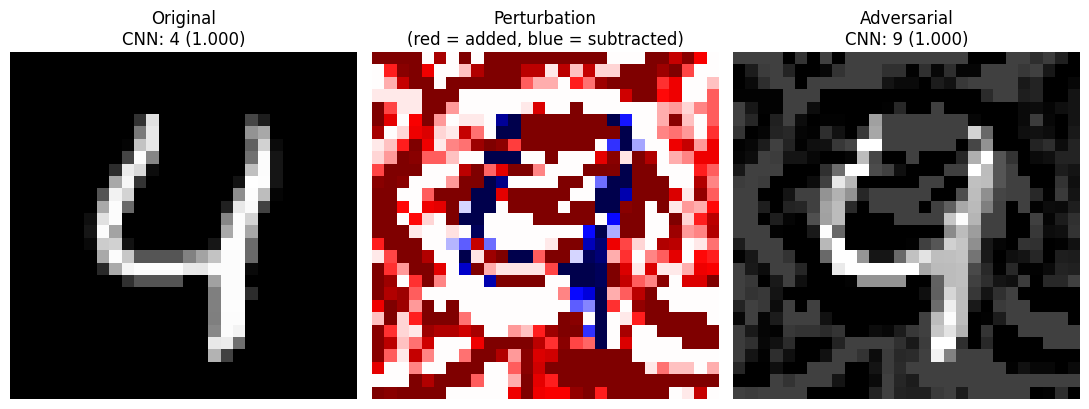

In [17]:
perturbation = (x_adv - x_orig).cpu().squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(11, 4))

axes[0].imshow(x_orig.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'Original\nCNN: {orig_probs.argmax()} ({orig_probs.max():.3f})')
axes[0].axis('off')

axes[1].imshow(perturbation, cmap='seismic', vmin=-0.25, vmax=0.25)
axes[1].set_title('Perturbation\n(red = added, blue = subtracted)')
axes[1].axis('off')

axes[2].imshow(x_adv.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f'Adversarial\nCNN: {adv_probs.argmax()} ({adv_probs.max():.3f})')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### Step 4 : Random noise that the CNN thinks is a 9

Instead of starting from a real image, we start from pure random noise, every pixel is a random number in [0, 1]. We then apply gradient descent on the pixels until the CNN classifies the noise as a "9".

Difference from Step 3: there is no "original image" to anchor to. We don't constrain the perturbation to be small. The optimization is unconstrained, provided the result is classified as a 9.

In [18]:
def noise_to_class(model, target_class, n_iter=300, lr=0.05):
    # Start from random noise and do gradient descent on the pixels until the model classifies it as target_class.
    x = torch.rand(1, 1, 28, 28, device=device)   # uniform noise in [0, 1]
    target = torch.tensor([target_class], device=device)

    for step in range(n_iter):
        x.requires_grad_(True)
        logits = model(x)
        loss = F.cross_entropy(logits, target)
        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            # Plain gradient step (not sign) — gives smoother results
            x = x - lr * x.grad
            x = torch.clamp(x, 0, 1)

    return x.detach()


# Save the starting noise so we can show it before-and-after
torch.manual_seed(42)
x_noise_start = torch.rand(1, 1, 28, 28, device=device)

# Run optimization (re-seed so it starts from the same noise)
torch.manual_seed(42)
x_fool = noise_to_class(model, target_class=9, n_iter=300, lr=0.05)

with torch.no_grad():
    start_probs = F.softmax(model(x_noise_start), dim=1).cpu().numpy()[0]
    fool_probs  = F.softmax(model(x_fool),       dim=1).cpu().numpy()[0]

print(f'Initial random noise: CNN said {start_probs.argmax()} (confidence {start_probs.max():.4f})')
print(f'After optimization:   CNN says {fool_probs.argmax()} (confidence {fool_probs.max():.4f})')

Initial random noise: CNN said 3 (confidence 0.5096)
After optimization:   CNN says 9 (confidence 0.9941)


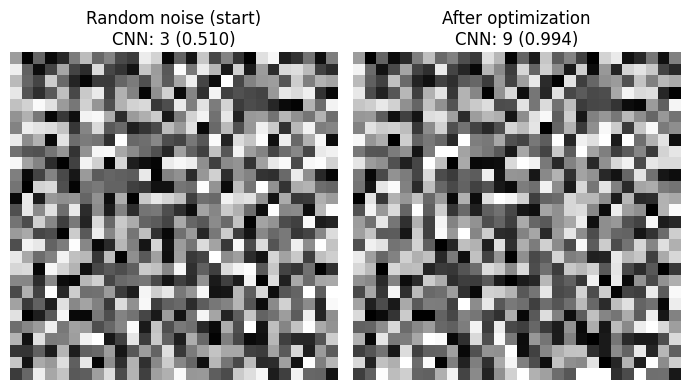

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(7, 4))
axes[0].imshow(x_noise_start.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'Random noise (start)\nCNN: {start_probs.argmax()} ({start_probs.max():.3f})')
axes[0].axis('off')
axes[1].imshow(x_fool.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'After optimization\nCNN: {fool_probs.argmax()} ({fool_probs.max():.3f})')
axes[1].axis('off')
plt.tight_layout(); plt.show()

The CNN reports over 99% confidence for class "9". The image may contain faint vertical strokes or curves that loosely resemble parts of a 9, but it does not look like a real handwritten 9. Despite this, the CNN's confidence is very high.


## Comparing the two attacks

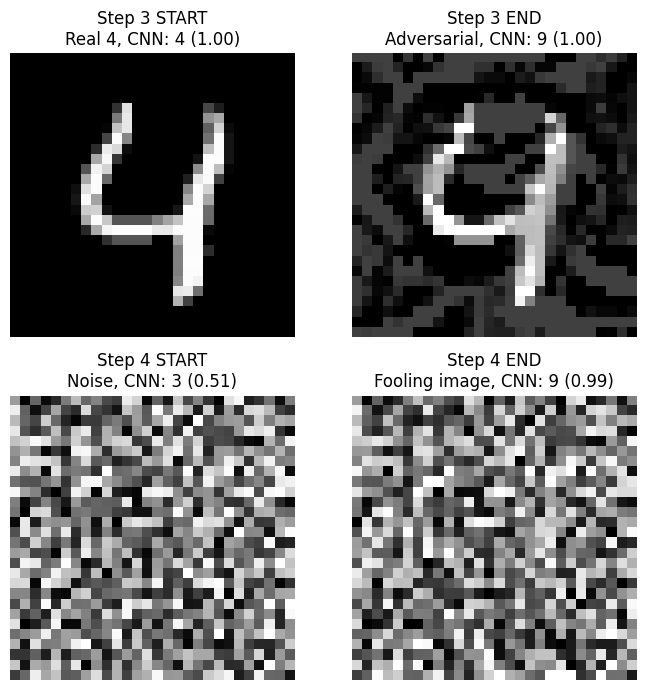

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(7, 7))

# Step 3: real 4 -> classified as 9
axes[0, 0].imshow(x_orig.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title(f'Step 3 START\nReal 4, CNN: {orig_probs.argmax()} ({orig_probs.max():.2f})')
axes[0, 0].axis('off')
axes[0, 1].imshow(x_adv.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title(f'Step 3 END\nAdversarial, CNN: {adv_probs.argmax()} ({adv_probs.max():.2f})')
axes[0, 1].axis('off')

# Step 4: noise -> classified as 9
axes[1, 0].imshow(x_noise_start.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title(f'Step 4 START\nNoise, CNN: {start_probs.argmax()} ({start_probs.max():.2f})')
axes[1, 0].axis('off')
axes[1, 1].imshow(x_fool.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[1, 1].set_title(f'Step 4 END\nFooling image, CNN: {fool_probs.argmax()} ({fool_probs.max():.2f})')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Reflection

### On Step 3 (real 4 -> adversarial 4)
The thing that surprised us most was how complete the flip was. The CNN went from being essentially 100% sure it's a 4 to being 100% sure it's a 9, yet the image still clearly looked like a 4 to us. The perturbation only used a max change of 0.25 per pixel, and even that small a change was enough.

This makes more sense once we think about it: the attack isn't adding random noise, it's adding noise aligned with the gradient. So even small steps push the input efficiently across the 4 vs 9 decision boundary.

### On Step 4 (noise -> "9")
The fooling image was the more unsettling result. Starting from pure random noise, after 300 iterations of gradient descent the CNN said "9" with 99.41% confidence, even though the image does not look like a 9 to a human. There's no constraint keeping the image close to anything natural, so the optimizer wandered into a region of input space the CNN happens to map to "9".

It made us realize that high softmax confidence is not the same as the model "really seeing" a 9. The CNN has high confidence regions all over the input space, including in places that look like noise.